In [18]:
# importação da biblioteca
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Biblioteca foram carregadas com sucesso!")

Biblioteca foram carregadas com sucesso!


In [19]:
from pathlib import Path

# Definir o nome do arquivo .csv usando o arquivo presente na pasta do notebook
caminho_base = Path.cwd()
nome_arquivo = caminho_base / "Dataset_sint_tico_de_voos.csv"

if nome_arquivo.exists():
    nome_arquivo = str(nome_arquivo)
    df = pd.read_csv(nome_arquivo, sep=',', encoding='utf-8', low_memory=False)
    df.columns = df.columns.str.lower()
    print(f"Arquivo {nome_arquivo} carregado com sucesso!")
    print('Dataframe criado!')
else:
    raise FileNotFoundError(f"Arquivo não encontrado: {nome_arquivo}")


Arquivo c:\Users\Halli\Desktop\IA Industrial Senai EAD\UC02 Atividades das aulas 08 e 15 setembro 2025\Resolução da atividade03\Dataset_sint_tico_de_voos.csv carregado com sucesso!
Dataframe criado!


In [20]:
print("Nomes originais das colunas:")
if 'df' in globals():
    print(df.columns)

    # conversão das colunas originais para minúsculas
    df.columns = df.columns.str.lower()

    print("\nNomes das colunas em minúsculas:")
    print(df.columns)
else:
    print("Variável 'df' não definida. Execute a célula que carrega o arquivo CSV (índice 2).")

Nomes originais das colunas:
Index(['fl_date', 'op_unique_carrier', 'tail_num', 'origin', 'dest',
       'crs_dep_time', 'dep_delay', 'arr_delay', 'distance'],
      dtype='str')

Nomes das colunas em minúsculas:
Index(['fl_date', 'op_unique_carrier', 'tail_num', 'origin', 'dest',
       'crs_dep_time', 'dep_delay', 'arr_delay', 'distance'],
      dtype='str')


In [21]:
import os

# Usa o caminho do arquivo já definido na célula anterior
if 'nome_arquivo' in globals() and os.path.exists(nome_arquivo):
    df = pd.read_csv(nome_arquivo, sep=",", encoding="utf-8", low_memory=False)
    df.columns = df.columns.str.lower()
    print(df.shape)
    print(df.head())
    print("Dimensões do conjunto de dados (dataframe)")
    print(df.shape)
    print("Amostragem de Dados (head - 5 primeiras linhas)")
    print(df.head())
    print("Amostragem dos últimos dados")
    print(df.tail())
    print("Informações gerais sobre os tipos de dados e valores nulos:")
    df.info(verbose=True)
else:
    print(f"Arquivo não encontrado: {nome_arquivo}")
    print("Verifique o caminho do arquivo ou carregue o arquivo no ambiente.")


(100, 9)
      fl_date op_unique_carrier tail_num origin dest  crs_dep_time  dep_delay  \
0  2023-01-01              AZUL    N1000    GIG  FOR          1369        7.0   
1  2023-01-02                SW    N1001    BSB  MIA          1986      -42.0   
2  2023-01-03             LATAM    N1002    ORD  REC          1534      -30.0   
3  2023-01-04              AZUL    N1003    JFK  FOR           146      -39.0   
4  2023-01-05                UA    N1004    GIG  SFO          1734      -24.0   

   arr_delay  distance  
0       32.0      4984  
1      -38.0      4200  
2       21.0      1833  
3       52.0      2352  
4       42.0       710  
Dimensões do conjunto de dados (dataframe)
(100, 9)
Amostragem de Dados (head - 5 primeiras linhas)
      fl_date op_unique_carrier tail_num origin dest  crs_dep_time  dep_delay  \
0  2023-01-01              AZUL    N1000    GIG  FOR          1369        7.0   
1  2023-01-02                SW    N1001    BSB  MIA          1986      -42.0   
2  2023-01-

In [22]:
# Verificar se df foi carregado, senão, carregá-lo
if 'df' not in globals():
    import os
    from pathlib import Path

    arquivo = Path.cwd() / "Dataset_sint_tico_de_voos.csv"
    if arquivo.exists():
        nome_arquivo = str(arquivo)
        df = pd.read_csv(nome_arquivo, sep=",", encoding="utf-8", low_memory=False)
        df.columns = df.columns.str.lower()
        print(f"Arquivo {nome_arquivo} carregado com sucesso!")
    else:
        raise FileNotFoundError(f"Arquivo não encontrado: {arquivo}")

# identificação de colunas numéricas (incluindo int e floats)
df_numericas = df.select_dtypes(include=np.number).columns.to_list()
print(df_numericas)

df_categoricas = df.select_dtypes(include='object').columns.to_list()
print("Colunas categóricas: \n", df_categoricas)

if 'op_unique_carrier' in df.columns:
    print("Valores únicos na coluna op_unique_carrier:")
    print(df['op_unique_carrier'].unique())


['crs_dep_time', 'dep_delay', 'arr_delay', 'distance']
Colunas categóricas: 
 ['fl_date', 'op_unique_carrier', 'tail_num', 'origin', 'dest']
Valores únicos na coluna op_unique_carrier:
<StringArray>
['AZUL', 'SW', 'LATAM', 'UA', 'DL', 'GOL', 'AA']
Length: 7, dtype: str


C:\Users\Halli\AppData\Local\Temp\ipykernel_12164\4286445238.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categoricas = df.select_dtypes(include='object').columns.to_list()


In [ ]:
valores_ausentes = df.isna().sum()

porcentagem_ausentes = (valores_ausentes / len(df) * 100).sort_values(ascending=False)

#Exibição do resultado
print("Porcentagem dos valores ausentes:")
print(valores_ausentes)

colunas_para_remover = porcentagem_ausentes[porcentagem_ausentes > 50].index

df.drop(columns=colunas_para_remover, inplace=True)
print(f"Colunas removidas por excesso de nulos: {list(colunas_para_remover)}")

for col in ['arr_delay', 'dep_delay']:
   if col in df.columns:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"Valores nulos da coluna {col} foram preenchidas com a mediana ({mediana})")

    print("Verificação de nulos após o tratamento inicial:")
    print(df.isna().sum().sort_values(ascending=False))

Porcentagem dos valores ausentes:
fl_date               0
op_unique_carrier     0
tail_num              0
origin                0
dest                  0
crs_dep_time          0
dep_delay            10
arr_delay            10
distance              0
dtype: int64
Colunas removidas por excesso de nulos: []
Valores nulos da coluna arr_delay foram preenchidas com a mediana (6.0)
Verificação de nulos após o tratamento inicial:
dep_delay            10
arr_delay            10
fl_date               0
op_unique_carrier     0
tail_num              0
origin                0
dest                  0
crs_dep_time          0
distance              0
dtype: int64
Valores nulos da coluna dep_delay foram preenchidas com a mediana (7.0)
Verificação de nulos após o tratamento inicial:
dep_delay            10
arr_delay            10
fl_date               0
op_unique_carrier     0
tail_num              0
origin                0
dest                  0
crs_dep_time          0
distance              0
dtype: in

C:\Users\Halli\AppData\Local\Temp\ipykernel_12164\2713573943.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(mediana, inplace=True)
C:\Users\Halli\AppData\Local\Temp\ipykernel_12164\2713573943.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an

In [24]:
# Converter a coluna de data para o formato datetime
if 'fl_date' in df.columns:
  df['fl_date'] = pd.to_datetime(df['fl_date'], format='%Y-%m-%d')
print("Coluna 'fl_date' convertida para o formato datetime")


# Remover os espaços em branco no inicio e no fim das colunas categoricas
for col in df_categoricas:
   if df[col].dtype == 'object':
    df[col] = df[col].str.strip()


print("Limpeza em colunas categoricas foi concluida com sucesso!")

Coluna 'fl_date' convertida para o formato datetime
Limpeza em colunas categoricas foi concluida com sucesso!


In [25]:
if 'arr_delay' in df.columns:
  df['Atraso_superior_15min'] = np.where(df['arr_delay'] > 15, 1, 0)
  print("Coluna 'Atraso_superior_15min' Criada com sucesso!")

  if'fl_date' in df.columns:
    df['Mes'] = df['fl_date'].dt.month
    df['Dia_da_Semana'] = df['fl_date'].dt.dayofweek
    print("Colunas 'Mes' e 'Dia_da_Semana' Criadas com sucesso!")

  if 'arr_delay' in df.columns:
    df['Atraso_absoluto'] = df['arr_delay'].abs()
    print("Coluna 'Atraso_Absoluto' Criada com sucesso!")

  display(df[['fl_date', 'arr_delay', 'Atraso_superior_15min', 'Mes', 'Dia_da_Semana', 'Atraso_absoluto']].head())

Coluna 'Atraso_superior_15min' Criada com sucesso!
Colunas 'Mes' e 'Dia_da_Semana' Criadas com sucesso!
Coluna 'Atraso_Absoluto' Criada com sucesso!


,fl_date,arr_delay,Atraso_superior_15min,Mes,Dia_da_Semana,Atraso_absoluto
0,2023-01-01,32.0,1,1,6,32.0
1,2023-01-02,-38.0,0,1,0,38.0
2,2023-01-03,21.0,1,1,1,21.0
3,2023-01-04,52.0,1,1,2,52.0
4,2023-01-05,42.0,1,1,3,42.0


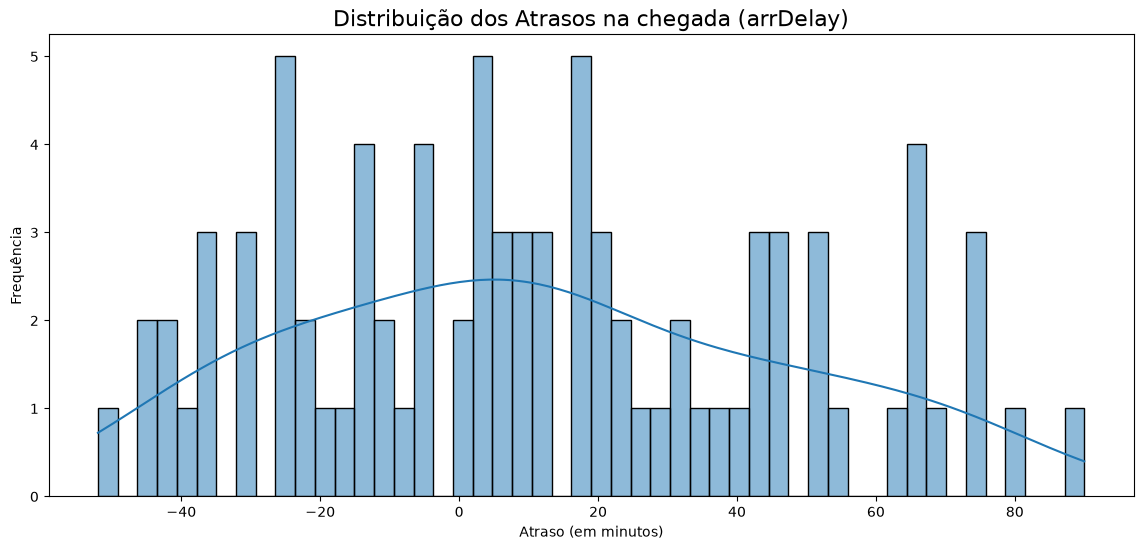

Text(0.5, 1.0, 'Boxplot dos Atrasos na chegada')

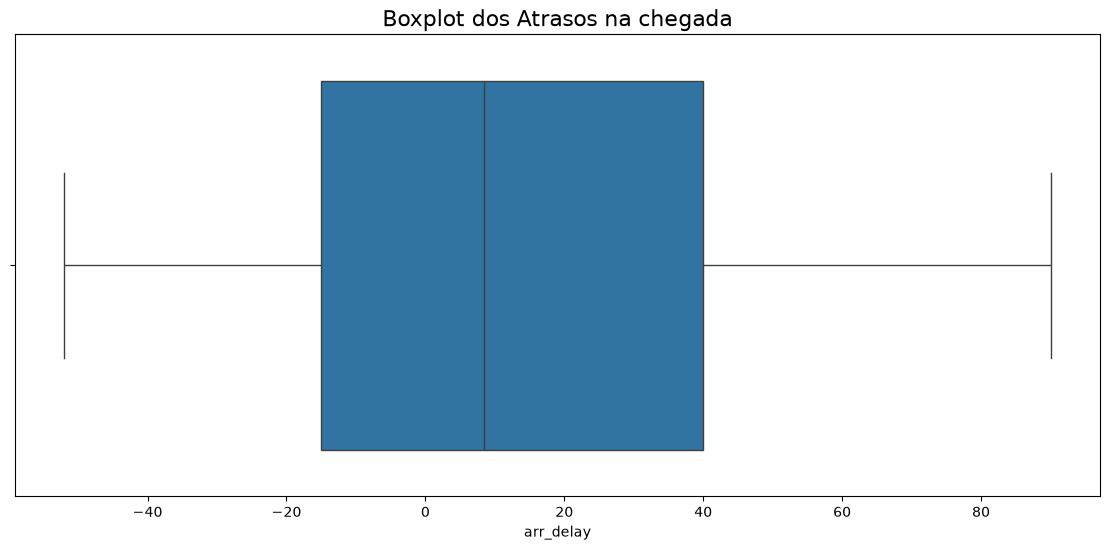

In [26]:
df_atraso_filtrada = df[df['arr_delay'].between(-60, 180)]

#histograma
plt.figure(figsize=(14, 6))

#Seaborn
sns.histplot(data=df_atraso_filtrada, x='arr_delay', bins=50, kde=True)
plt.title("Distribuição dos Atrasos na chegada (arrDelay)",fontsize=16)
plt.xlabel("Atraso (em minutos)",fontsize=10)
plt.ylabel("Frequência",fontsize=10)
plt.show()

#Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_atraso_filtrada, x='arr_delay')
plt.title("Boxplot dos Atrasos na chegada",fontsize=16)

origin
BSB    19.200000
GIG    17.125000
GRU    16.333333
LAX    12.555556
JFK     0.615385
ORD    -1.666667
ATL    -3.923077
Name: dep_delay, dtype: float64


C:\Users\Halli\AppData\Local\Temp\ipykernel_12164\3256973570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_atraso_aeroport.index, y=media_atraso_aeroport.values, palette='viridis')


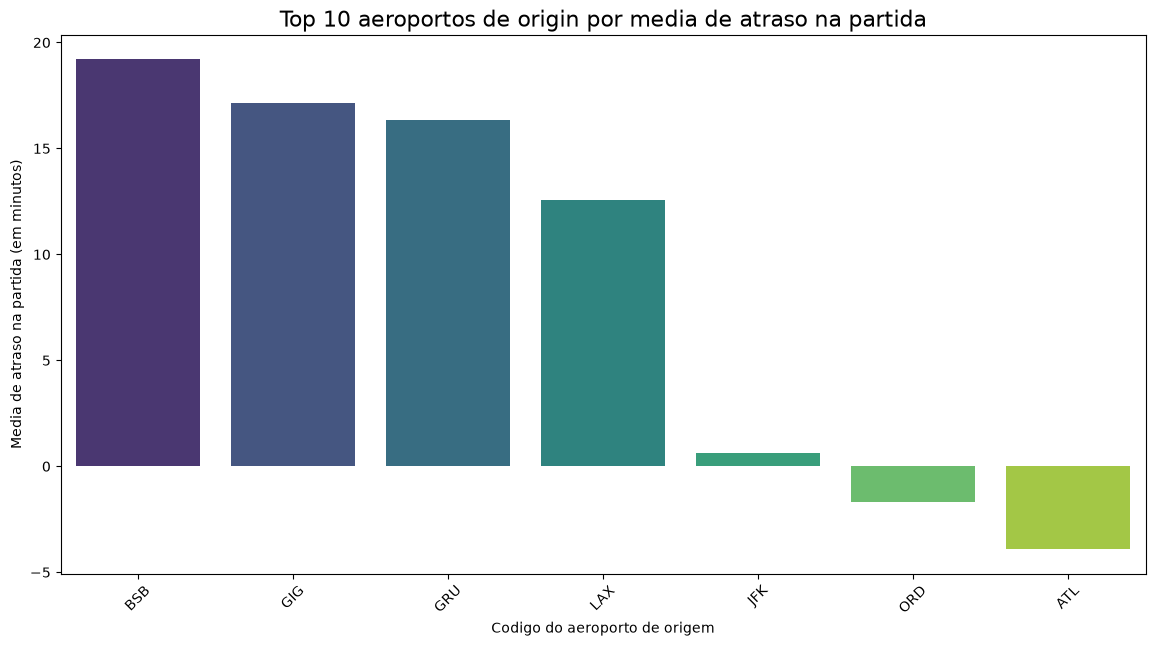

In [27]:
#Calcular a media de atraso na partida por aeroporto de origem
if 'origin' in df.columns and 'dep_delay' in df.columns:
  media_atraso_aeroport = df.groupby('origin')['dep_delay'].mean().sort_values(ascending=False).head(10)
  print(media_atraso_aeroport)

  #Gráfico de barras
  plt.figure(figsize=(14, 7))
  sns.barplot(x=media_atraso_aeroport.index, y=media_atraso_aeroport.values, palette='viridis')
  plt.title("Top 10 aeroportos de origin por media de atraso na partida",fontsize=16)
  plt.xlabel("Codigo do aeroporto de origem")
  plt.ylabel("Media de atraso na partida (em minutos)")
  plt.xticks(rotation=45)
  plt.show()
else:
  print('Erro!')



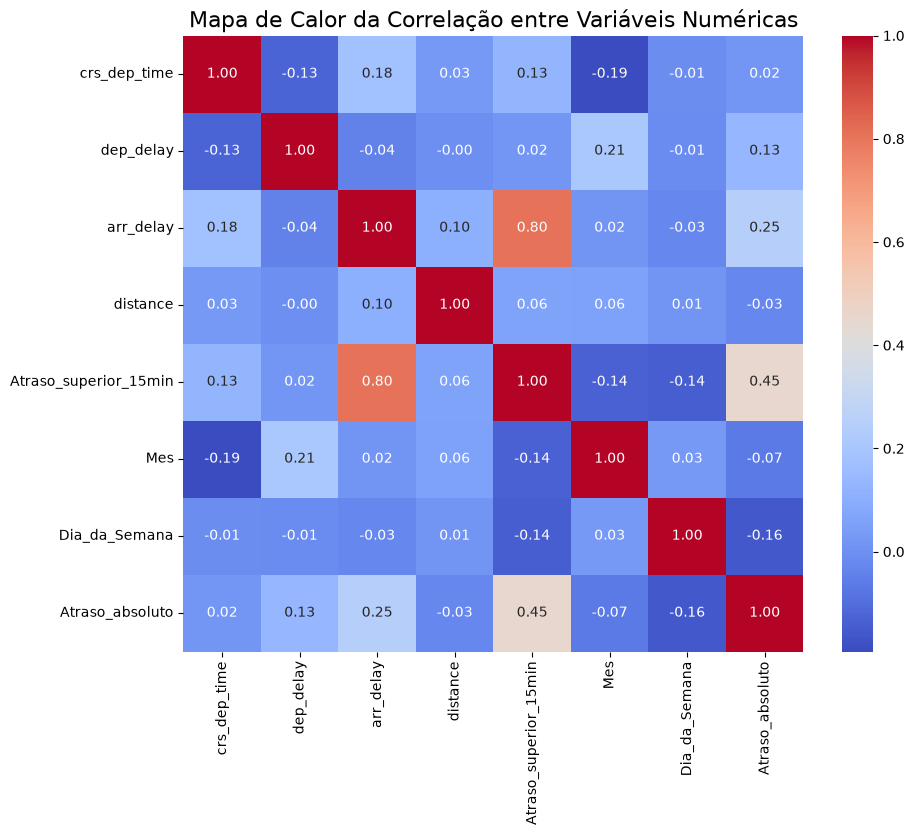

In [28]:
# Calcular a matriz de correlação
# A função describe() tambem é util parqa obter estatisticas numéricas antes da correlação[cite: 63]
matriz_correlacao = df.select_dtypes(include=np.number).corr()

# Desenhe o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação entre Variáveis Numéricas', fontsize=16)
plt.show()